# Модул 3: Decision Trees - Интерпретируемост
## Структура, Визуализация и Обяснения на Дървета за Решения

**Цели:**
- Разбиране на структурата на Decision Trees
- Глобална интерпретируемост - Feature Importance
- Локална интерпретируемост - Decision Paths
- Визуализация на дървета
- Извличане на правила от дървета
- Trade-off между точност и интерпретируемост

---

## СПРАВОЧЕН ЛИСТ

### Структура на Decision Tree:
- **Root Node** - Първият възел (най-информативният split)
- **Internal Nodes** - Възли с условия за split
- **Leaf Nodes** - Крайни възли с предсказания
- **Depth** - Брой нива от root до leaf
- **Gini Impurity** - Мярка за "нечистота" (0 = pure)

### Sklearn DecisionTree:
```python
DecisionTreeClassifier(max_depth, min_samples_split, min_samples_leaf)
model.fit(X, y)                    # Обучение
model.predict(X)                   # Предсказване
model.feature_importances_         # Feature importance scores
model.tree_                        # Достъп до структурата
```

### Визуализация:
```python
from sklearn.tree import plot_tree, export_text
plot_tree(model, feature_names, class_names, filled=True)
export_text(model, feature_names)  # Текстово представяне
```

### Decision Path:
```python
model.decision_path(X)             # Път на предсказване
model.apply(X)                     # Индекс на leaf node
```

### Feature Importance методи:
1. **Impurity-based** - Намаление на Gini/Entropy
2. **Depth-based** - Колко близо до root е feature
3. **Frequency-based** - Колко често се използва feature

---

## Част 1: Подготовка на данните

In [1]:
# Задача 1.1: Импортирайте библиотеките
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Настройки
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

print("Библиотеките са заредени успешно!")

Библиотеките са заредени успешно!


In [2]:
# Задача 1.2: Заредете и подгответе Titanic датасета
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv(
    '/content/drive/MyDrive/XAI/Titanic-Dataset.csv'
)

# Запазваме само полезните колони
columns = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
df = df[columns].copy()

# Обработка на липсващи стойности
# Попълнете метода за изчисляване на медианата
df['Age'].fillna(df['Age'].median(), inplace=True)
# Попълнете метода за намиране на най-честата стойност (mode)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Енкодиране на категорийни променливи
# Попълнете числовите стойности за mapping (male=0, female=1)
df['Sex'] = df['Sex'].map({'male':0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print(f"Данни подготвени: {df.shape}")
df.head()

Mounted at /content/drive
Данни подготвени: (891, 8)


/tmp/ipython-input-3029629406.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipython-input-3029629406.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


In [3]:
# Задача 1.3: Разделете на X и y, после на train/test

# Попълнете името на target колоната, която трябва да премахнем от X
X = df.drop('Survived', axis=1)
y = df['Survived']

feature_names = X.columns.tolist()
class_names = ['Не оцелял', 'Оцелял']

# Попълнете размера на тестовата извадка (20% = 0.2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} примера")
print(f"Test set: {len(X_test)} примера")
print(f"\nFeatures: {feature_names}")

Training set: 712 примера
Test set: 179 примера

Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


## Част 2: Създаване на Интерпретируемо Дърво

За интерпретируемост, дълбочината на дървото е критична - по-плитки дървета са по-лесни за разбиране.

In [4]:
# Задача 2.1: Създайте дърво с ограничена дълбочина (max_depth=3)
# Това ще бъде нашето "интерпретируемо" дърво

tree_simple = DecisionTreeClassifier(
    # Попълнете максималната дълбочина за интерпретируемо дърво
    max_depth=3,
    min_samples_split=10,
    random_state=42
)

# Попълнете метода за обучение на модела
tree_simple.fit(X_train, y_train)

# Оценка
# Попълнете метода за генериране на предсказания
y_pred_simple = tree_simple.predict(X_test)
accuracy_simple = accuracy_score(y_test, y_pred_simple)

print(f"Точност на простото дърво (depth=3): {accuracy_simple:.2%}")

Точност на простото дърво (depth=3): 79.89%


In [5]:
# Задача 2.2: Създайте дълбоко дърво за сравнение
tree_complex = DecisionTreeClassifier(
    # Попълнете стойността за без ограничение на дълбочината
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

tree_complex.fit(X_train, y_train);

y_pred_complex = tree_complex.predict(X_test)
accuracy_complex = accuracy_score(y_test, y_pred_complex)

# Попълнете метода за получаване на дълбочината на дървото
print(f"Точност на сложното дърво (без ограничение): {accuracy_complex:.2%}")
print(f"\nСравнение:")
print(f"  Просто дърво (depth=3):  {accuracy_simple:.2%}")
print(f"  Сложно дърво (depth={tree_complex.tree_.max_depth}): {accuracy_complex:.2%}")
print(f"  Разлика: {accuracy_complex - accuracy_simple:.2%}")

Точност на сложното дърво (без ограничение): 79.89%

Сравнение:
  Просто дърво (depth=3):  79.89%
  Сложно дърво (depth=21): 79.89%
  Разлика: 0.00%


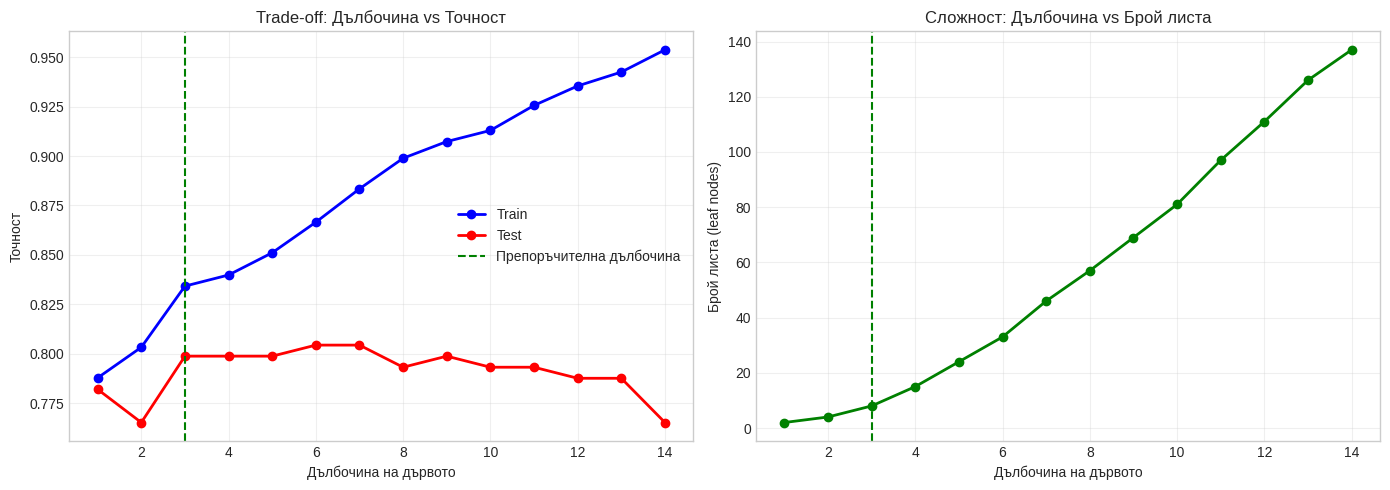


При depth=3: 8 листа - лесно за интерпретация
При depth=14: 137 листа - почти невъзможно за интерпретация


In [6]:
# Задача 2.3: Анализирайте trade-off между дълбочина и точност

depths = range(1, 15)
train_scores = []
test_scores = []
n_leaves = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)

    # Попълнете метода за изчисляване на точността (score)
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))
    # Попълнете метода за получаване на броя листа
    n_leaves.append(tree.tree_.n_leaves)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Точност vs Дълбочина
axes[0].plot(depths, train_scores, 'b-o', label='Train', linewidth=2)
axes[0].plot(depths, test_scores, 'r-o', label='Test', linewidth=2)
axes[0].axvline(x=3, color='green', linestyle='--', label='Препоръчителна дълбочина')
axes[0].set_xlabel('Дълбочина на дървото')
axes[0].set_ylabel('Точност')
axes[0].set_title('Trade-off: Дълбочина vs Точност')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Брой листа vs Дълбочина
axes[1].plot(depths, n_leaves, 'g-o', linewidth=2)
axes[1].axvline(x=3, color='green', linestyle='--')
axes[1].set_xlabel('Дълбочина на дървото')
axes[1].set_ylabel('Брой листа (leaf nodes)')
axes[1].set_title('Сложност: Дълбочина vs Брой листа')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nПри depth=3: {n_leaves[2]} листа - лесно за интерпретация")
print(f"При depth=14: {n_leaves[-1]} листа - почти невъзможно за интерпретация")

## Част 3: Визуализация на Дървото

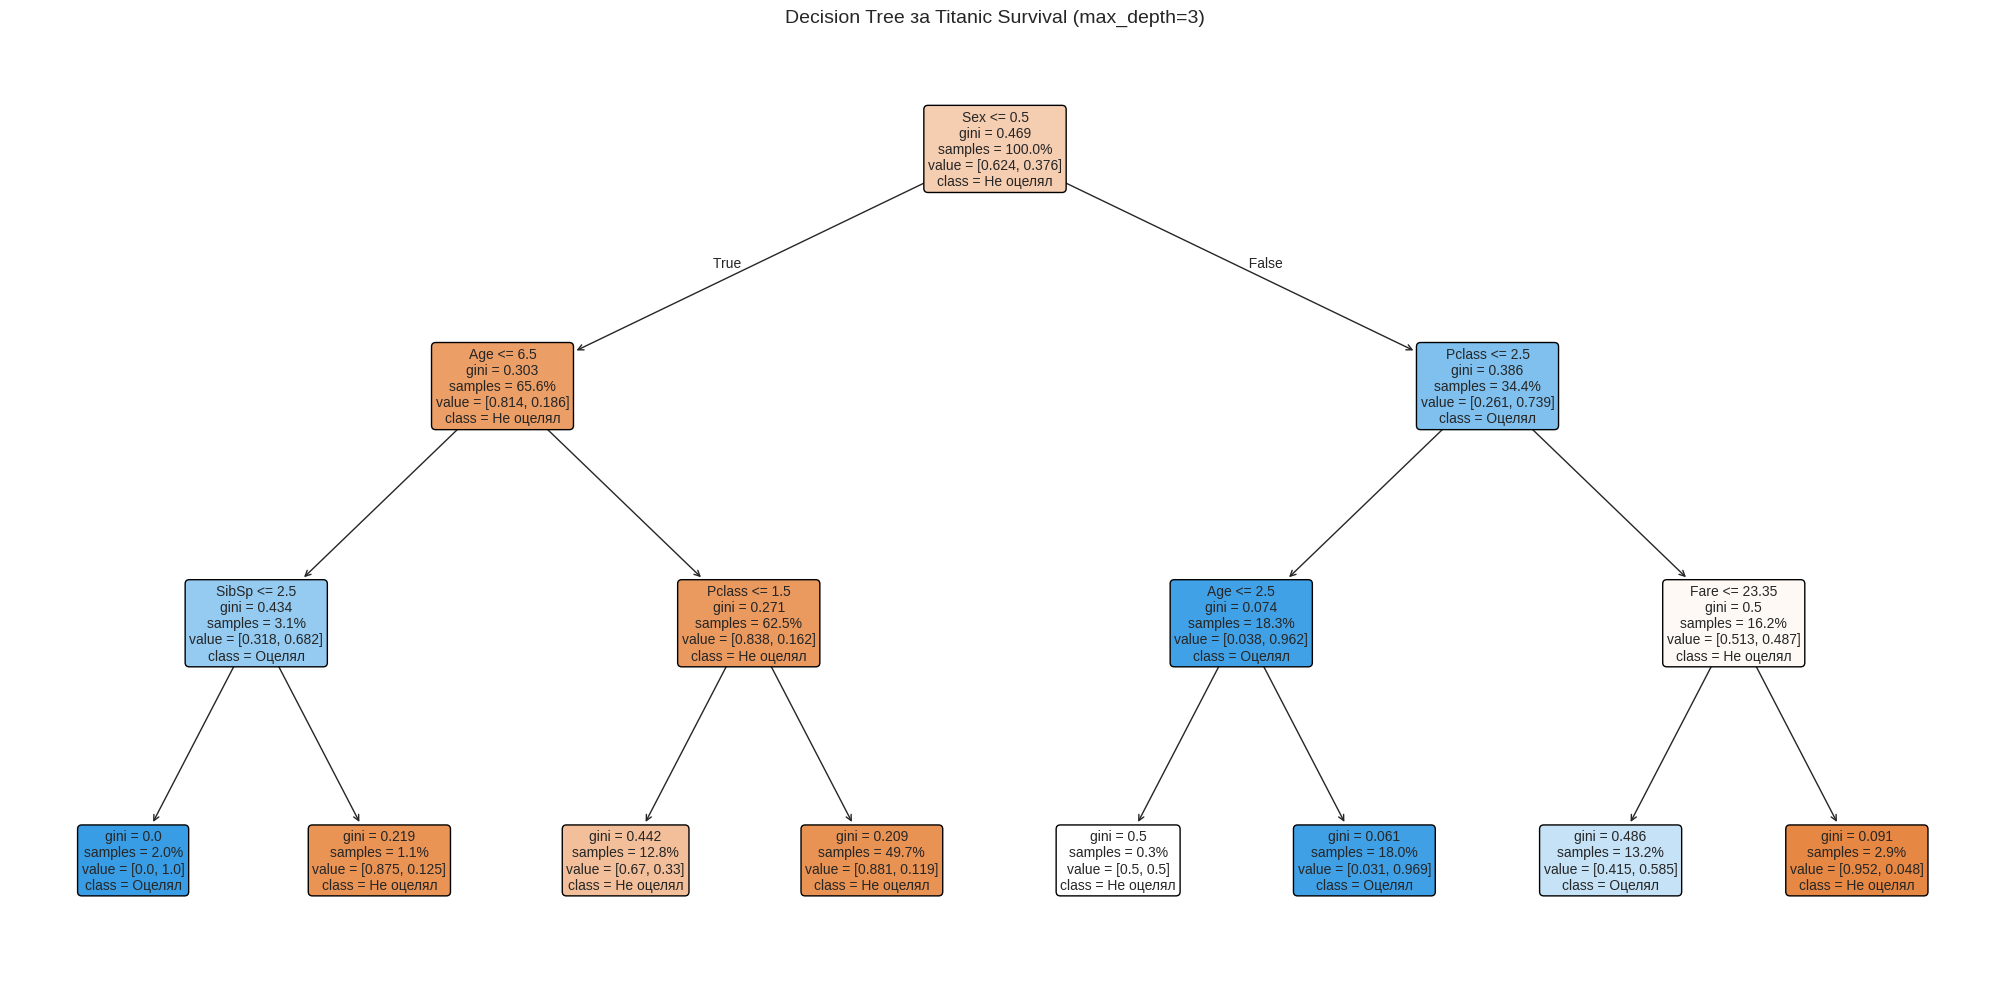

In [7]:
# Задача 3.1: Визуализирайте простото дърво графично

plt.figure(figsize=(20, 10))
plot_tree(
    tree_simple,
    feature_names=feature_names,
    class_names=class_names,
    # Попълнете параметъра за оцветяване по клас (True/False)
    filled=True,
    # Попълнете параметъра за заоблени ъгли (True/False)
    rounded=True,
    fontsize=10,
    proportion=True  # Показва пропорции вместо абсолютни числа
)
plt.title('Decision Tree за Titanic Survival (max_depth=3)', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Задача 3.2: Извлечете текстово представяне на дървото

tree_rules = export_text(
    tree_simple,
    feature_names=feature_names
)

print("ПРАВИЛА НА ДЪРВОТО:")
print("="*50)
print(tree_rules)

ПРАВИЛА НА ДЪРВОТО:
|--- Sex <= 0.50
|   |--- Age <= 6.50
|   |   |--- SibSp <= 2.50
|   |   |   |--- class: 1
|   |   |--- SibSp >  2.50
|   |   |   |--- class: 0
|   |--- Age >  6.50
|   |   |--- Pclass <= 1.50
|   |   |   |--- class: 0
|   |   |--- Pclass >  1.50
|   |   |   |--- class: 0
|--- Sex >  0.50
|   |--- Pclass <= 2.50
|   |   |--- Age <= 2.50
|   |   |   |--- class: 0
|   |   |--- Age >  2.50
|   |   |   |--- class: 1
|   |--- Pclass >  2.50
|   |   |--- Fare <= 23.35
|   |   |   |--- class: 1
|   |   |--- Fare >  23.35
|   |   |   |--- class: 0



In [9]:
# Задача 3.3: Конвертирайте правилата в човешки четим формат

def extract_rules(tree, feature_names, class_names):
    """
    Извлича правила от decision tree в четим формат.
    """
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != -2 else "undefined!"
        for i in tree_.feature
    ]

    rules = []

    def recurse(node, depth, path):
        indent = "  " * depth

        if tree_.feature[node] != -2:  # Internal node
            name = feature_name[node]
            threshold = tree_.threshold[node]

            # Ляв клон (<=)
            recurse(tree_.children_left[node], depth + 1,
                   path + [(name, "<=", threshold)])

            # Десен клон (>)
            recurse(tree_.children_right[node], depth + 1,
                   path + [(name, ">", threshold)])
        else:  # Leaf node
            class_label = class_names[np.argmax(tree_.value[node])]
            samples = tree_.n_node_samples[node]
            rules.append((path, class_label, samples))

    recurse(0, 0, [])
    return rules

rules = extract_rules(tree_simple, feature_names, class_names)

print("\nИЗВЛЕЧЕНИ ПРАВИЛА (IF-THEN формат):")
print("="*70)

for i, (path, class_label, samples) in enumerate(rules[:5], 1):  # Показваме първите 5
    conditions = " AND ".join([f"{f} {op} {t:.2f}" for f, op, t in path])
    print(f"\nПравило {i}: ({samples} примера)")
    print(f"  IF {conditions}")
    print(f"  THEN -> {class_label}")


ИЗВЛЕЧЕНИ ПРАВИЛА (IF-THEN формат):

Правило 1: (14 примера)
  IF Sex <= 0.50 AND Age <= 6.50 AND SibSp <= 2.50
  THEN -> Оцелял

Правило 2: (8 примера)
  IF Sex <= 0.50 AND Age <= 6.50 AND SibSp > 2.50
  THEN -> Не оцелял

Правило 3: (91 примера)
  IF Sex <= 0.50 AND Age > 6.50 AND Pclass <= 1.50
  THEN -> Не оцелял

Правило 4: (354 примера)
  IF Sex <= 0.50 AND Age > 6.50 AND Pclass > 1.50
  THEN -> Не оцелял

Правило 5: (2 примера)
  IF Sex > 0.50 AND Pclass <= 2.50 AND Age <= 2.50
  THEN -> Не оцелял


## Част 4: Глобална Интерпретируемост - Feature Importance

In [10]:
# Задача 4.1: Извлечете feature importance от дървото

# Попълнете атрибута за извличане на feature importance

importance = tree_simple.feature_importances_

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("Feature Importance (Gini-based):")
df_importance


Feature Importance (Gini-based):


,Feature,Importance
1,Sex,0.605737
0,Pclass,0.209536
2,Age,0.075353
5,Fare,0.061240
3,SibSp,0.048135
4,Parch,0.000000
6,Embarked,0.000000


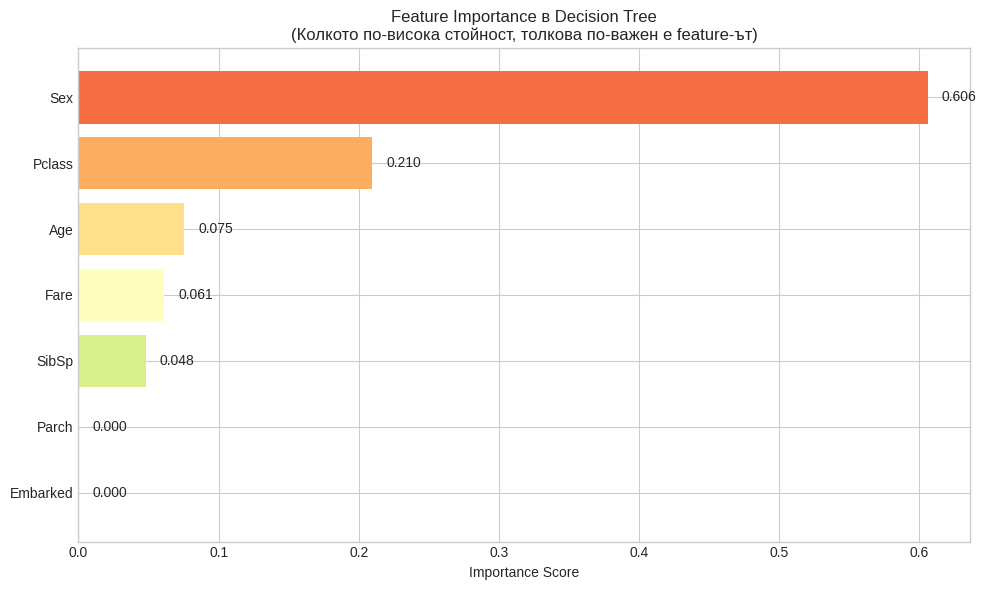

In [11]:
# Задача 4.2: Визуализирайте feature importance

plt.figure(figsize=(10, 6))

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(df_importance)))
bars = plt.barh(df_importance['Feature'], df_importance['Importance'], color=colors)

plt.xlabel('Importance Score')
plt.title('Feature Importance в Decision Tree\n(Колкото по-висока стойност, толкова по-важен е feature-ът)')
plt.gca().invert_yaxis()  # Най-важният отгоре

# Добавяме стойности върху баровете
for bar, val in zip(bars, df_importance['Importance']):
    plt.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [12]:
# Задача 4.3: Интерпретирайте резултатите

print("\nИНТЕРПРЕТАЦИЯ НА FEATURE IMPORTANCE:")
print("="*60)

top_feature = df_importance.iloc[0]
print(f"\n1. Най-важен feature: {top_feature['Feature']}")
print(f"   Importance: {top_feature['Importance']:.3f}")

if top_feature['Feature'] == 'Sex':
    print("   Интерпретация: Полът е най-важният фактор за оцеляване.")
    print("   Жените са имали много по-голям шанс за оцеляване (\"Women and children first\")")

print(f"\n2. Features с importance = 0:")
zero_importance = df_importance[df_importance['Importance'] == 0]['Feature'].tolist()
if zero_importance:
    print(f"   {', '.join(zero_importance)}")
    print("   Тези features не са използвани от дървото при depth=3")
else:
    print("   Всички features са използвани")


ИНТЕРПРЕТАЦИЯ НА FEATURE IMPORTANCE:

1. Най-важен feature: Sex
   Importance: 0.606
   Интерпретация: Полът е най-важният фактор за оцеляване.
   Жените са имали много по-голям шанс за оцеляване ("Women and children first")

2. Features с importance = 0:
   Parch, Embarked
   Тези features не са използвани от дървото при depth=3


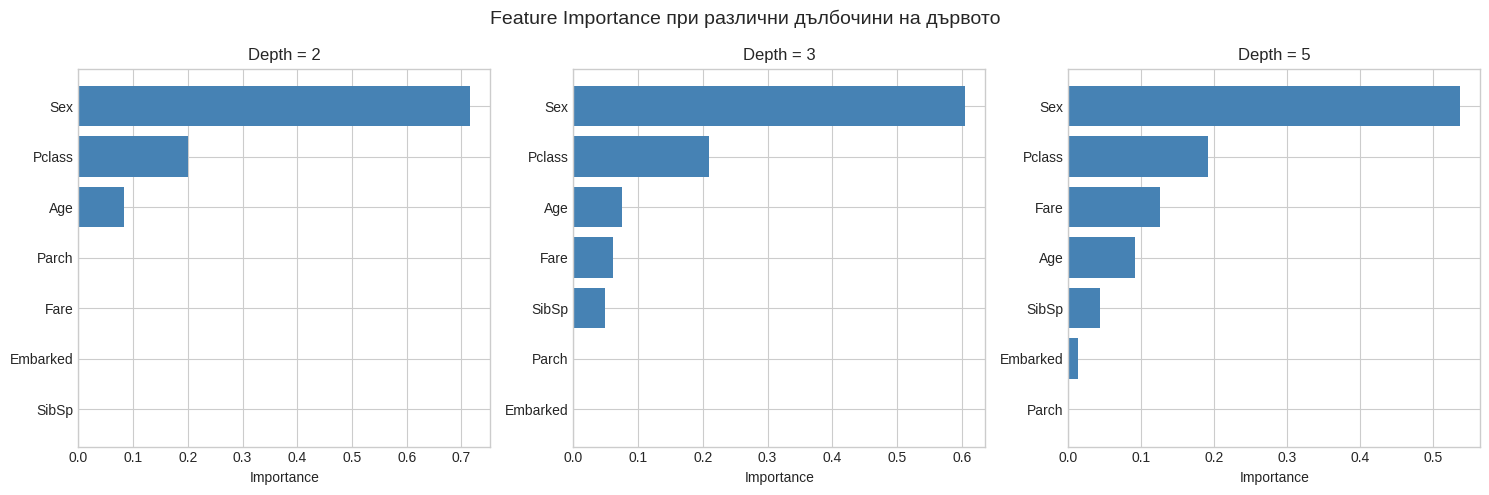

In [13]:
# Задача 4.4: Сравнете importance при различни дълбочини

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, depth in enumerate([2, 3, 5]):
    tree_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree_temp.fit(X_train, y_train)

    imp = pd.Series(tree_temp.feature_importances_, index=feature_names).sort_values()

    axes[i].barh(imp.index, imp.values, color='steelblue')
    axes[i].set_title(f'Depth = {depth}')
    axes[i].set_xlabel('Importance')

plt.suptitle('Feature Importance при различни дълбочини на дървото', fontsize=14)
plt.tight_layout()
plt.show()

## Част 5: Локална Интерпретируемост - Decision Paths

In [14]:
# Задача 5.1: Изберете конкретен пример за обяснение

# Взимаме първите 3 примера от тестовия набор
# Попълнете метода за избиране на първите 3 реда
examples = X_test.head(3)
examples_target = y_test.head(3)

print("Примери за анализ:")
print(examples)
print(f"\nДействителен резултат: {examples_target.values}")
# Попълнете метода за генериране на предсказания
print(f"Предсказан резултат: {tree_simple.predict(examples)}")

Примери за анализ:
     Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
709       3    0  28.0      1      1  15.2458         1
439       2    0  31.0      0      0  10.5000         0
840       3    0  20.0      0      0   7.9250         0

Действителен резултат: [1 0 0]
Предсказан резултат: [0 0 0]


In [15]:
# Задача 5.2: Създайте функция за обяснение на индивидуално предсказване

def explain_prediction(tree, X_instance, feature_names, class_names):
    """
    Генерира обяснение за конкретно предсказване.

    Връща текстово обяснение на решението.
    """
    tree_ = tree.tree_

    # Вземаме пътя на решение
    node_indicator = tree.decision_path(X_instance.values.reshape(1, -1))
    node_indices = node_indicator.indices

    # Предсказание
    prediction = tree.predict(X_instance.values.reshape(1, -1))[0]
    proba = tree.predict_proba(X_instance.values.reshape(1, -1))[0]

    print("="*60)
    print("ОБЯСНЕНИЕ НА ПРЕДСКАЗВАНЕТО")
    print("="*60)

    print("\nВходни данни:")
    for feature, value in zip(feature_names, X_instance.values):
        print(f"   {feature}: {value}")

    print("\nПът на решение:")
    for i, node_id in enumerate(node_indices):
        if tree_.feature[node_id] != -2:  # Не е leaf
            feature_idx = tree_.feature[node_id]
            threshold = tree_.threshold[node_id]
            feature_value = X_instance.values[feature_idx]
            feature_name = feature_names[feature_idx]

            if feature_value <= threshold:
                decision = "<="
            else:
                decision = ">"

            print(f"   Стъпка {i+1}: {feature_name} = {feature_value:.2f} {decision} {threshold:.2f}")

    print(f"\nРЕЗУЛТАТ:")
    print(f"   Предсказание: {class_names[prediction]}")
    print(f"   Увереност: {class_names[0]}: {proba[0]:.1%}, {class_names[1]}: {proba[1]:.1%}")

    return prediction, proba

In [16]:
# Задача 5.3: Обяснете първия пример

example_1 = examples.iloc[0]
pred, proba = explain_prediction(tree_simple, example_1, feature_names, class_names)

ОБЯСНЕНИЕ НА ПРЕДСКАЗВАНЕТО

Входни данни:
   Pclass: 3.0
   Sex: 0.0
   Age: 28.0
   SibSp: 1.0
   Parch: 1.0
   Fare: 15.2458
   Embarked: 1.0

Път на решение:
   Стъпка 1: Sex = 0.00 <= 0.50
   Стъпка 2: Age = 28.00 > 6.50
   Стъпка 3: Pclass = 3.00 > 1.50

РЕЗУЛТАТ:
   Предсказание: Не оцелял
   Увереност: Не оцелял: 88.1%, Оцелял: 11.9%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [17]:
# Задача 5.4: Обяснете втория пример

example_2 = examples.iloc[1]
pred2, proba2 = explain_prediction(tree_simple, example_2, feature_names, class_names)

ОБЯСНЕНИЕ НА ПРЕДСКАЗВАНЕТО

Входни данни:
   Pclass: 2.0
   Sex: 0.0
   Age: 31.0
   SibSp: 0.0
   Parch: 0.0
   Fare: 10.5
   Embarked: 0.0

Път на решение:
   Стъпка 1: Sex = 0.00 <= 0.50
   Стъпка 2: Age = 31.00 > 6.50
   Стъпка 3: Pclass = 2.00 > 1.50

РЕЗУЛТАТ:
   Предсказание: Не оцелял
   Увереност: Не оцелял: 88.1%, Оцелял: 11.9%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


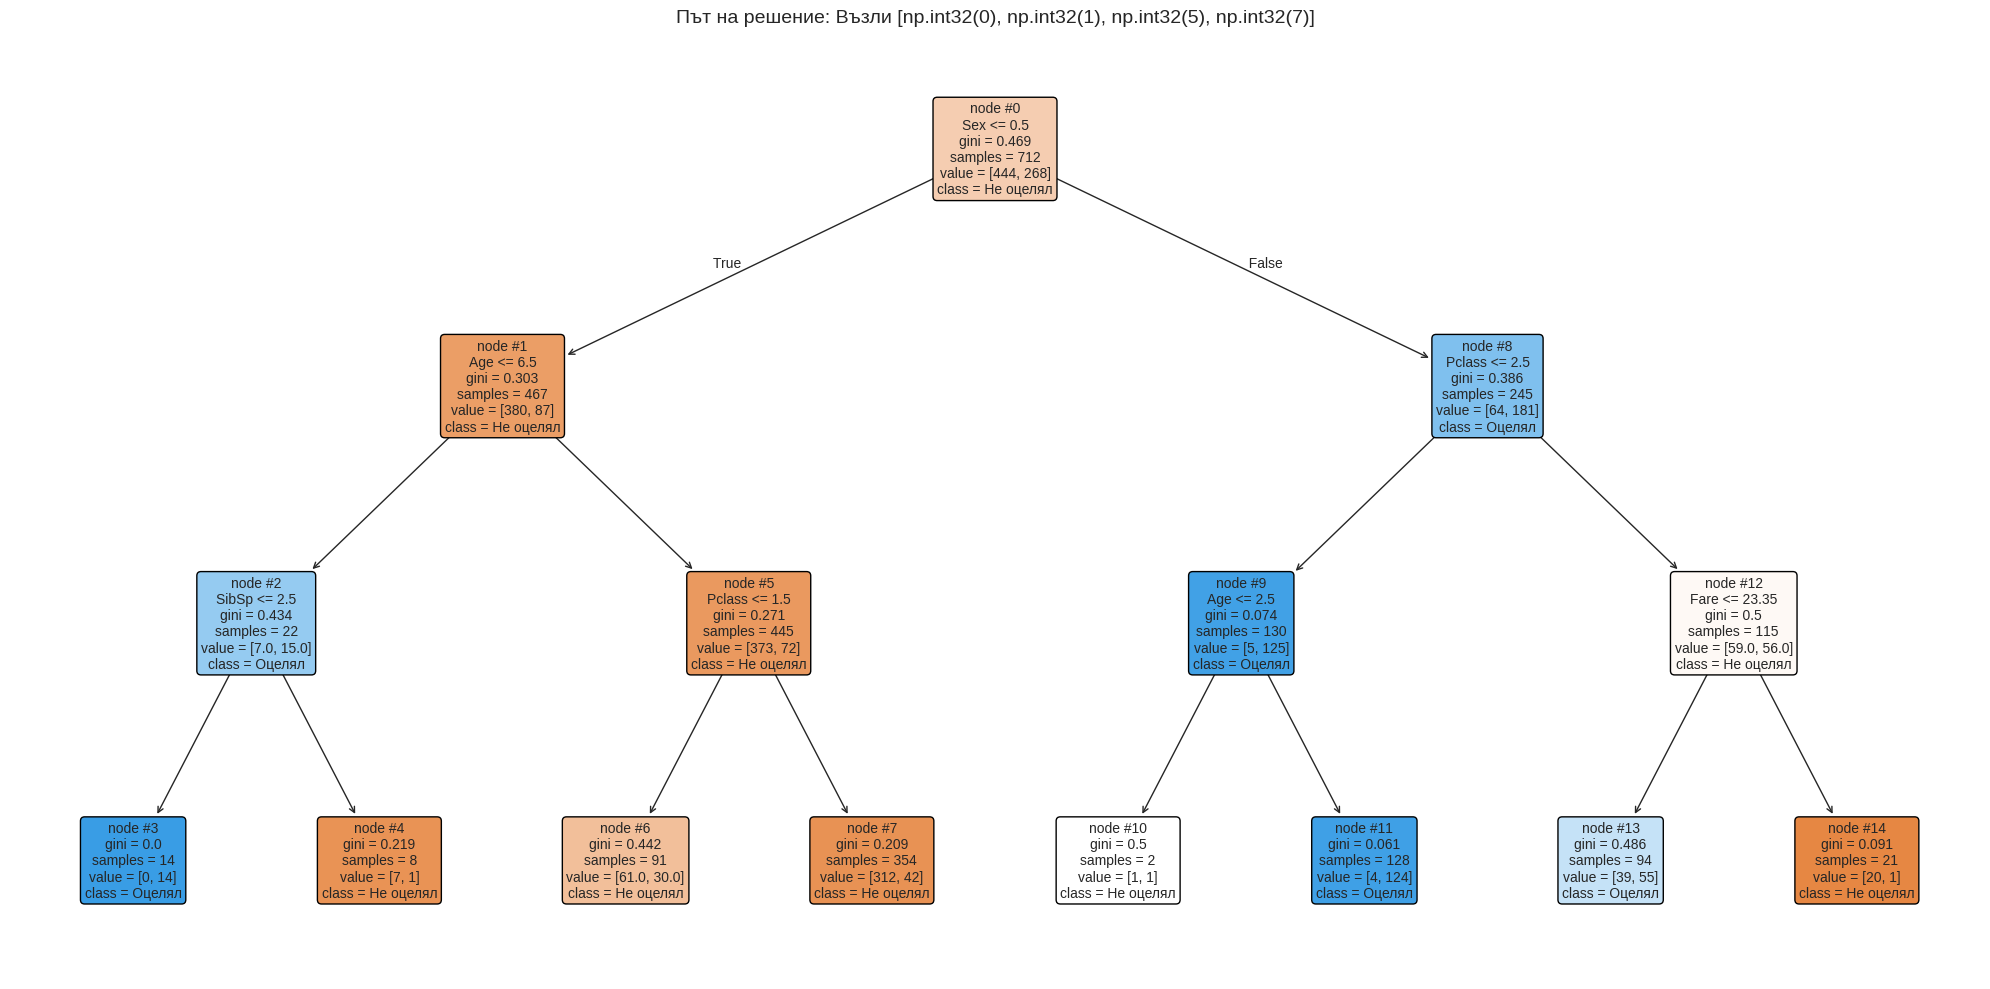

In [18]:
# Задача 5.5: Визуализирайте пътя на решение

def visualize_path(tree, X_instance, feature_names, class_names):
    """
    Визуализира пътя на решение в дървото.
    """
    node_indicator = tree.decision_path(X_instance.values.reshape(1, -1))

    plt.figure(figsize=(20, 10))
    plot_tree(
        tree,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        rounded=True,
        fontsize=10,
        node_ids=True  # Показва ID на възлите
    )

    plt.title(f'Път на решение: Възли {list(node_indicator.indices)}', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_path(tree_simple, example_1, feature_names, class_names)

In [19]:
# Задача 5.6: Създайте "counterfactual" обяснение
# Какво би трябвало да се промени, за да се получи различен резултат?

def counterfactual_explanation(tree, X_instance, feature_names, class_names):
    """
    Генерира counterfactual обяснение - какво трябва да се промени
    за различен резултат.
    """
    tree_ = tree.tree_
    prediction = tree.predict(X_instance.values.reshape(1, -1))[0]

    # Вземаме пътя
    node_indicator = tree.decision_path(X_instance.values.reshape(1, -1))
    node_indices = node_indicator.indices

    print("\nCOUNTERFACTUAL АНАЛИЗ")
    print("="*60)
    print(f"Текущо предсказание: {class_names[prediction]}")
    print(f"\nЗа да получите '{class_names[1-prediction]}', бихте могли да промените:")

    for node_id in node_indices:
        if tree_.feature[node_id] != -2:
            feature_idx = tree_.feature[node_id]
            threshold = tree_.threshold[node_id]
            feature_value = X_instance.values[feature_idx]
            feature_name = feature_names[feature_idx]

            if feature_value <= threshold:
                print(f"   - {feature_name}: от {feature_value:.2f} на > {threshold:.2f}")
            else:
                print(f"   - {feature_name}: от {feature_value:.2f} на <= {threshold:.2f}")

counterfactual_explanation(tree_simple, example_1, feature_names, class_names)


COUNTERFACTUAL АНАЛИЗ
Текущо предсказание: Не оцелял

За да получите 'Оцелял', бихте могли да промените:
   - Sex: от 0.00 на > 0.50
   - Age: от 28.00 на <= 6.50
   - Pclass: от 3.00 на <= 1.50


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Част 6: Извличане на Decision Rules

In [20]:
# Задача 6.1: Създайте пълен списък с правила

def extract_all_rules(tree, feature_names, class_names):
    """
    Извлича всички правила от дървото.
    """
    tree_ = tree.tree_
    rules_list = []

    def recurse(node, conditions):
        if tree_.feature[node] != -2:  # Internal node
            feature_name = feature_names[tree_.feature[node]]
            threshold = tree_.threshold[node]

            # Ляв клон
            recurse(tree_.children_left[node],
                   conditions + [f"{feature_name} <= {threshold:.2f}"])

            # Десен клон
            recurse(tree_.children_right[node],
                   conditions + [f"{feature_name} > {threshold:.2f}"])
        else:  # Leaf node
            values = tree_.value[node][0]
            class_label = class_names[np.argmax(values)]
            confidence = max(values) / sum(values)
            samples = int(sum(values))

            rule = {
                'conditions': conditions,
                'class_label': class_label,
                'confidence': confidence,
                'samples': samples
            }
            rules_list.append(rule)

    recurse(0, [])
    return rules_list

all_rules = extract_all_rules(tree_simple, feature_names, class_names)

print("ПЪЛЕН СПИСЪК С ПРАВИЛА:")
print("="*70)

for i, rule in enumerate(all_rules, 1):
    print(f"\nПравило {i} ({rule['samples']} примера, {rule['confidence']:.1%} увереност):")
    print(f"  IF {' AND '.join(rule['conditions'])}")
    print(f"  THEN -> {rule['class_label']}")

ПЪЛЕН СПИСЪК С ПРАВИЛА:

Правило 1 (1 примера, 100.0% увереност):
  IF Sex <= 0.50 AND Age <= 6.50 AND SibSp <= 2.50
  THEN -> Оцелял

Правило 2 (1 примера, 87.5% увереност):
  IF Sex <= 0.50 AND Age <= 6.50 AND SibSp > 2.50
  THEN -> Не оцелял

Правило 3 (1 примера, 67.0% увереност):
  IF Sex <= 0.50 AND Age > 6.50 AND Pclass <= 1.50
  THEN -> Не оцелял

Правило 4 (1 примера, 88.1% увереност):
  IF Sex <= 0.50 AND Age > 6.50 AND Pclass > 1.50
  THEN -> Не оцелял

Правило 5 (1 примера, 50.0% увереност):
  IF Sex > 0.50 AND Pclass <= 2.50 AND Age <= 2.50
  THEN -> Не оцелял

Правило 6 (1 примера, 96.9% увереност):
  IF Sex > 0.50 AND Pclass <= 2.50 AND Age > 2.50
  THEN -> Оцелял

Правило 7 (1 примера, 58.5% увереност):
  IF Sex > 0.50 AND Pclass > 2.50 AND Fare <= 23.35
  THEN -> Оцелял

Правило 8 (1 примера, 95.2% увереност):
  IF Sex > 0.50 AND Pclass > 2.50 AND Fare > 23.35
  THEN -> Не оцелял


In [21]:
# Задача 6.2: Намерете най-важните правила (с най-много примери)

rules_df = pd.DataFrame(all_rules)
rules_df['rule_text'] = rules_df['conditions'].apply(lambda x: ' AND '.join(x))
rules_df = rules_df.sort_values('samples', ascending=False)

print("\nТОП 3 ПРАВИЛА (по брой примери):")
print("="*70)

for i, row in rules_df.head(3).iterrows():
    print(f"\n- {row['rule_text']}")
    print(f"  -> {row['class_label']} ({row['samples']} примера, {row['confidence']:.1%} увереност)")


ТОП 3 ПРАВИЛА (по брой примери):

- Sex <= 0.50 AND Age <= 6.50 AND SibSp <= 2.50
  -> Оцелял (1 примера, 100.0% увереност)

- Sex <= 0.50 AND Age <= 6.50 AND SibSp > 2.50
  -> Не оцелял (1 примера, 87.5% увереност)

- Sex <= 0.50 AND Age > 6.50 AND Pclass <= 1.50
  -> Не оцелял (1 примера, 67.0% увереност)


## Модул 3 Завършен!

### Основни изводи:
1. **По-плитки дървета** са по-лесни за интерпретация, но може да са по-малко точни
2. **Feature Importance** показва кои features са глобално важни
3. **Decision Paths** обясняват конкретни предсказания
4. **Decision Rules** могат да се извлекат и използват директно
5. **Counterfactual обяснения** показват какво трябва да се промени за различен резултат


---

## Въпроси за самопроверка:

1. Какво е Gini Impurity и как се използва в Decision Trees?
**Gini Impurity** измерва колко „смесени“ са класовете в даден възел и се използва в Decision Trees за избор на разделяне, което максимално увеличава чистотата на възлите
2. Защо дълбочина 3 е добър избор за интерпретируемост?**Дълбочина 3** е добър избор за интерпретируемост, защото дървото остава компактно и лесно разбираемо за човек, без дълги и сложни правила
3. Каква е разликата между глобална и локална интерпретируемост?
**Глобалната интерпретируемост** обяснява как моделът работи като цяло, докато локалната интерпретируемост обяснява защо е взето конкретно решение за даден пример.
4. Как Feature Importance се изчислява в Decision Trees?
**Feature Importance в Decision Trees** се изчислява като сумата от намалението на Gini Impurity, което всеки feature постига при всички разделяния в дървото
5. Какво е counterfactual обяснение и защо е полезно?5. **Counterfactual обяснение** показва каква минимална промяна във входните данни би довела до различен изход и е полезно, защото дава конкретни и разбираеми насоки за действи